<a href="https://colab.research.google.com/github/VinceGarcia11/Melbourne_Housing/blob/main/Data_Mining.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
import pandas as pd
from scipy import stats
from sklearn.cluster import KMeans
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, classification_report

#reading the data
url = "https://raw.githubusercontent.com/VinceGarcia11/Melbourne_Housing/refs/heads/main/melb_data.csv"
house = pd.read_csv(url)
house.head()


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,85 Turner St,2,h,1480000,S,Biggin,3/12/2016,2.5,3067,...,1,1.0,202,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019
1,Abbotsford,25 Bloomburg St,2,h,1035000,S,Biggin,4/2/2016,2.5,3067,...,1,0.0,156,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019
2,Abbotsford,5 Charles St,3,h,1465000,SP,Biggin,4/3/2017,2.5,3067,...,2,0.0,134,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019
3,Abbotsford,40 Federation La,3,h,850000,PI,Biggin,4/3/2017,2.5,3067,...,2,1.0,94,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019
4,Abbotsford,55a Park St,4,h,1600000,VB,Nelson,4/6/2016,2.5,3067,...,1,2.0,120,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019


**bold text**

In [18]:
#X
h = house.drop(['Address', 'Method', 'SellerG', 'Postcode'], axis=1)
h1 = pd.get_dummies( h, drop_first=True)
# Replacing NaN values with 0
X =  h1.fillna(0)


In [19]:
#categorical variable
#Create a random 80/20 split
#creating the split
x_train, x_test = train_test_split(X, test_size = 0.20, random_state = 7)


In [20]:
print(x_train.shape)
print(x_test.shape)

(10864, 423)
(2716, 423)


In [21]:
import statsmodels.tools.tools as stattools
from sklearn.tree import DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestRegressor
#Target Variable
y_train = x_train['Price']
#Target Variable
y_test = x_test['Price']

rf01 = RandomForestRegressor(n_estimators = 100, min_samples_leaf = 10, max_depth = 5).fit(x_train, y_train)
predict = rf01.predict(x_test)

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
# 1. R-Squared (0 to 1 scale, higher is better)
r2 = r2_score(y_test, predict) #generated by Gemini AI

# 2. Mean Absolute Error (Average dollar amount you are off by)
mae = mean_absolute_error(y_test, predict) #generated by Gemini AI

print(f"R2 Score: {r2:.4f}") #generated by Gemini AI
print(f"Average Error: ${mae:,.2f}") #generated by Gemini AI

R2 Score: 0.9945
Average Error: $11,701.72


In [23]:
print(f"Training Accuracy: {rf01.score(x_train, y_train):.2f}") #generated by Gemini to check accuracy

Training Accuracy: 1.00


In [24]:
cart01 = DecisionTreeClassifier(criterion = "gini", max_leaf_nodes=30).fit(x_train, y_train)

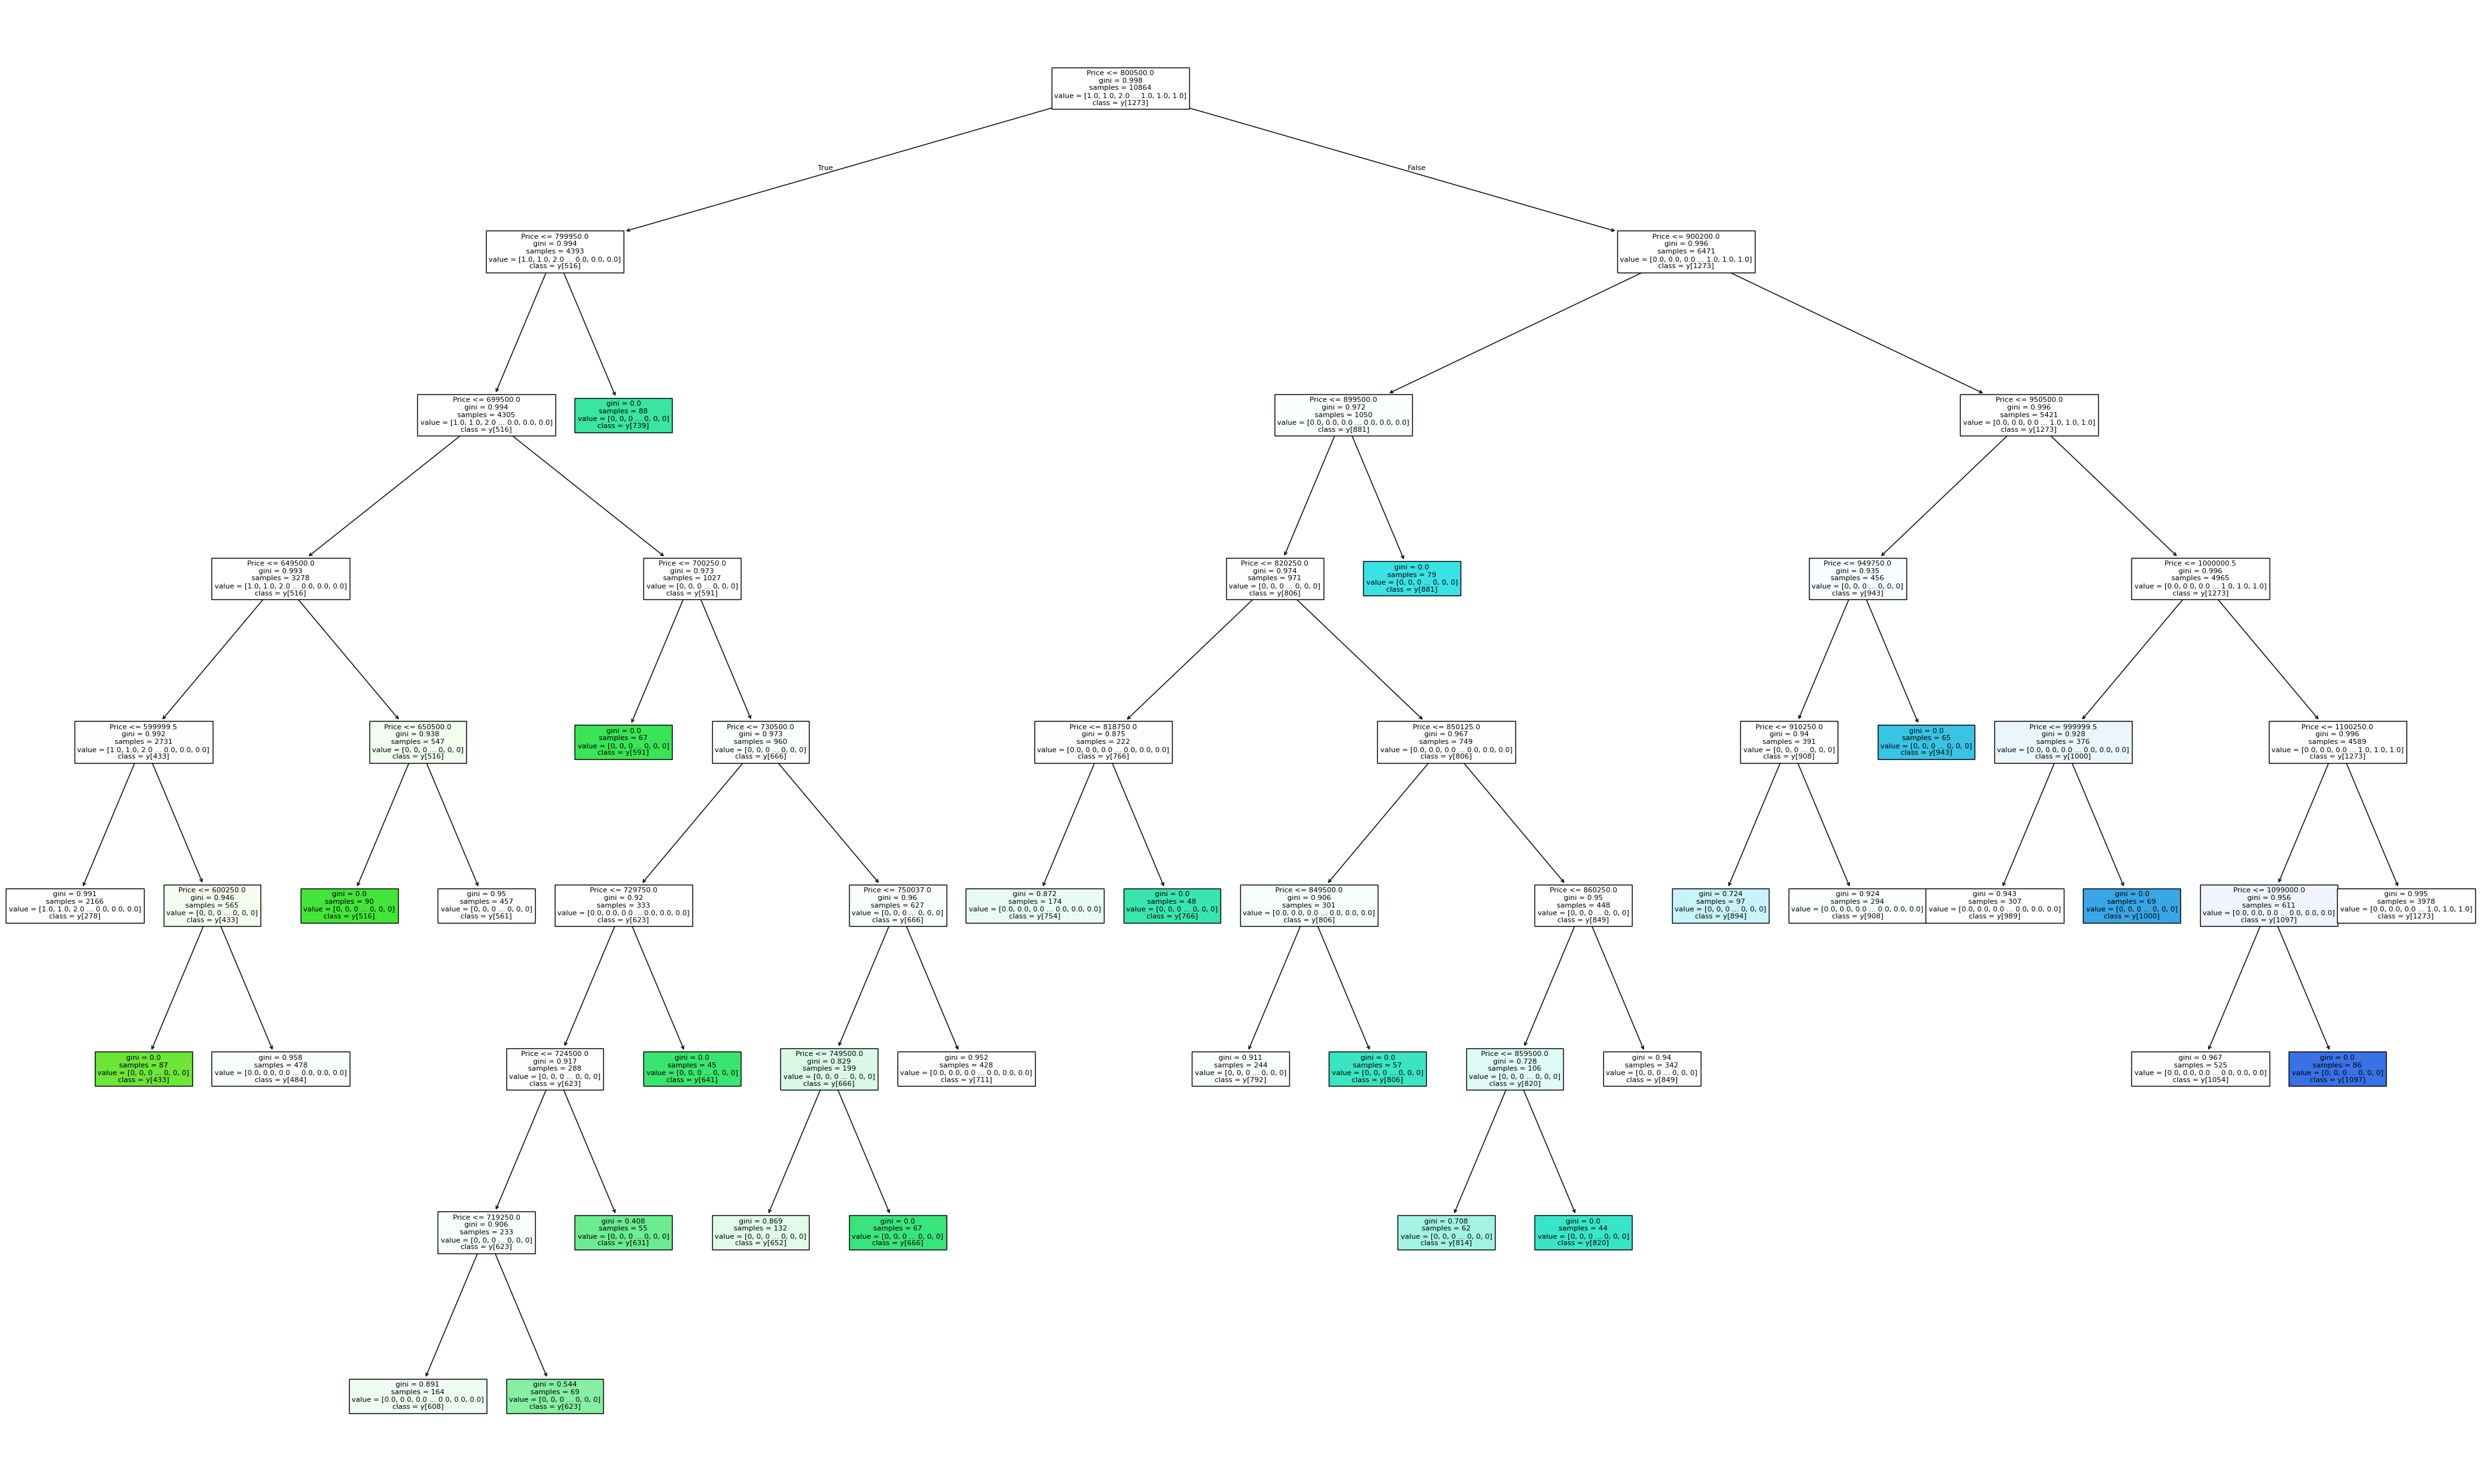

In [25]:
import matplotlib.pyplot as plt
from sklearn import tree

# Custom color function applied to nodes
fig, ax = plt.subplots(figsize=(50,30))
tree.plot_tree(cart01,
               feature_names=x_train.columns,
               class_names=True,
               filled=True,
               ax=ax)  # plot_tree doesn't directly support custom node functions, so this step remains simple
plt.show()
#source:
#https://www.geeksforgeeks.org/machine-learning/changing-colors-for-decision-tree-plot-using-sklearn-plot-tree/

In [26]:
# Create price/sq.ft. feature
house['price_per_sqft'] = house['Price'] / house['BuildingArea']

house = house.dropna(subset=['Price', 'BuildingArea', 'Regionname'])
house = house[house['BuildingArea'] > 0]

print(house.groupby('Regionname')['price_per_sqft'].describe())

                             count          mean           std          min  \
Regionname                                                                    
Eastern Metropolitan         708.0   9574.485161  33273.813628   188.484759   
Eastern Victoria              30.0   4517.782284   1589.979568   786.618445   
Northern Metropolitan       2090.0  12299.391950  52770.260581   261.382799   
Northern Victoria             28.0   3625.640609   1664.691556    30.439178   
South-Eastern Metropolitan   220.0   7701.725874  19814.806803   853.766617   
Southern Metropolitan       2409.0  14789.484298  89030.060858   474.695708   
Western Metropolitan        1607.0   8234.273167  20521.138092   707.142857   
Western Victoria              21.0   4061.400197   3443.223692  1600.000000   

                                    25%          50%           75%  \
Regionname                                                           
Eastern Metropolitan        5416.666667  6614.593230   8271.926338   

In [28]:
# Encode region
le = LabelEncoder()
house['region_encoded'] = le.fit_transform(house['Regionname'])

X = house[['region_encoded']]
y_reg = house['price_per_sqft']

# CART
X_train, X_test, y_train, y_test = train_test_split(X, y_reg, test_size=0.2, random_state=42)
cart = DecisionTreeRegressor(max_depth=4, random_state=42)
cart.fit(X_train, y_train)
y_pred = cart.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"CART RMSE: {rmse:.2f}")

CART RMSE: 36728.65


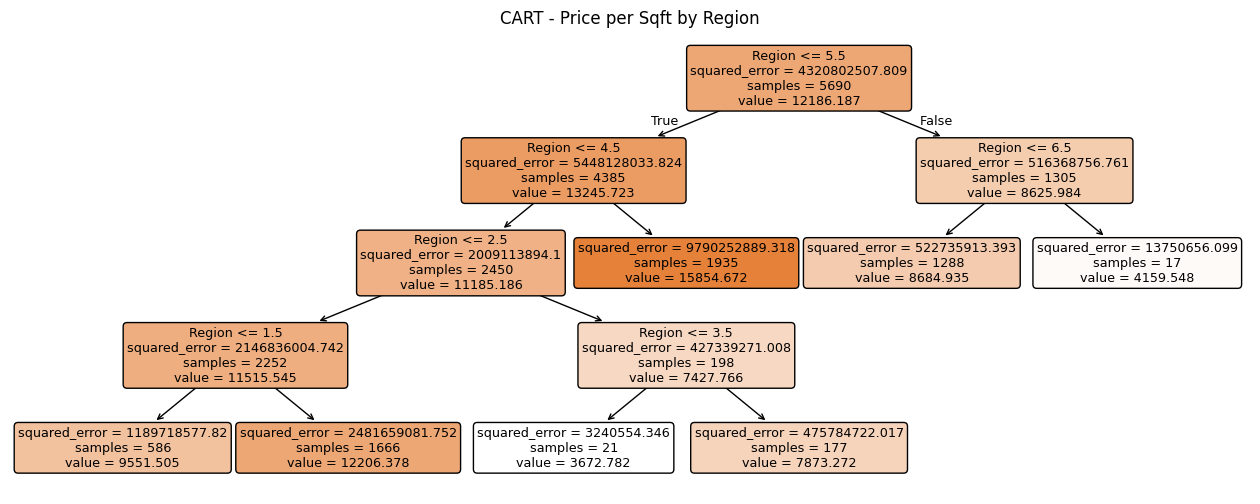

In [29]:
plt.figure(figsize=(16, 6))
plot_tree(cart, feature_names=['Region'], filled=True, rounded=True)
plt.title("CART - Price per Sqft by Region")
plt.show()